In [ ]:
import sys
!{sys.executable} -m pip install cloudscraper mplcyberpunk beautifulsoup4 pandas lxml

In [7]:
import io
import os
import sys
import pandas as pd
import cloudscraper
import yfinance as yf
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcyberpunk
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# =============================================================================
# DATA FETCHING LOGIC
# =============================================================================
def fetch_combined_analytics():
    """
    Scrapes ETF flows from Farside and synchronizes with BTC price from Yahoo Finance.
    """
    print("[*] Connecting to data providers...")
    try:
        # 1. Scraping ETF Flows with Cloudscraper
        scraper = cloudscraper.create_scraper(
            browser={'browser': 'chrome', 'platform': 'windows', 'desktop': True}
        )
        response = scraper.get("https://farside.co.uk/btc/", timeout=30)
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Identify the correct table containing 'IBIT'
        html_table = next(t for t in soup.find_all('table') if 'IBIT' in t.text)
        df_etf = pd.read_html(io.StringIO(str(html_table)))[0]
        
        # Clean MultiIndex and empty structures
        df_etf = df_etf.dropna(how='all').dropna(axis=1, how='all')
        df_etf = df_etf.iloc[:, [0, -1]].copy()
        df_etf.columns = ['RawDate', 'Total']
        
        # Filter for valid date rows and convert
        df_etf = df_etf[df_etf['RawDate'].astype(str).str.contains(r'\d', na=False)]
        df_etf['Date'] = pd.to_datetime(df_etf['RawDate'], errors='coerce')
        df_etf = df_etf.dropna(subset=['Date']).sort_values('Date')
        
        # Financial cleaning (brackets to negatives)
        def clean_fin(v):
            s = str(v).replace(',', '').replace('$', '').replace('(', '-').replace(')', '').strip()
            try: return float(''.join(c for c in s if c in '0123456789.-'))
            except: return 0.0
            
        df_etf['Total'] = df_etf['Total'].apply(clean_fin)
        
        # Focus on the last 14 entries for better visual correlation
        df_etf = df_etf.tail(90)
        df_etf['Cumulative'] = df_etf['Total'].cumsum()

        # 2. Fetching BTC Price via YFinance
        start_date = df_etf['Date'].min().strftime('%Y-%m-%d')
        btc = yf.download("BTC-USD", start=start_date, interval="1d", progress=False)
        
        if isinstance(btc.columns, pd.MultiIndex):
            btc.columns = btc.columns.get_level_values(0)
            
        # Synchronize datasets
        df_final = pd.merge(df_etf, btc[['Close']], left_on='Date', right_index=True, how='left')
        df_final['Close'] = df_final['Close'].ffill()
        
        # NEW: Calculate Pearson Correlation
        correlation = df_final['Cumulative'].corr(df_final['Close'])
        
        return df_final, correlation # Changed to return two values

    except Exception as e:
        print(f"[!] Critical data error: {e}")
        return None

# =============================================================================
# VISUALIZATION LOGIC
# =============================================================================

def plot_correlation_dashboard(df, correlation):
    """
    Renders a 3-axis dashboard. 
    """
    import numpy as np
    import matplotlib.patches as mpatches
    import matplotlib.dates as mdates

    if df is None or df.empty:
        print("[!] Error: DataFrame is empty.")
        return

    df = df.copy()
    
    if 'Date' in df.columns:
        plot_dates = pd.to_datetime(df['Date']).values
    else:
        plot_dates = pd.to_datetime(df.index).values

    plot_total = pd.to_numeric(df['Total'], errors='coerce').fillna(0).values
    plot_cum = pd.to_numeric(df['Cumulative'], errors='coerce').ffill().values
    plot_close = pd.to_numeric(df['Close'], errors='coerce').ffill().values

    print(f"[*] Plotting correlation for {len(df)} entries...")
    
    plt.style.use("cyberpunk")
    fig, ax_daily = plt.subplots(figsize=(14, 7), facecolor='#0d1117')
    
    CYAN, MAGENTA, GOLD = '#00d9ff', '#fe53bb', '#f39c12'
    GREEN, RED = '#2ecc71', '#e74c3c'

    # --- 1. Daily Flows ---
    colors = [GREEN if x >= 0 else RED for x in plot_total]
    ax_daily.bar(plot_dates, plot_total, color=colors, alpha=0.15, width=0.5)
    
    for i in range(len(df)):
        v = plot_total[i]
        if not np.isnan(v) and v != 0:
            ax_daily.text(plot_dates[i], v, f'{int(v)}', 
                          color='white', ha='center', va='bottom' if v > 0 else 'top', 
                          fontsize=8, alpha=0.8, fontweight='bold')

    ax_daily.set_ylabel('Daily Flow ($M)', color=GREEN, fontsize=10, fontweight='bold')
    ax_daily.tick_params(axis='y', labelcolor=GREEN)
    ax_daily.grid(False)
    
    # FIX: Smart axis scaling
    # Force axis to match actual data range
    ymin = min(plot_total) * 1.2 if min(plot_total) < 0 else min(plot_total) * 0.8
    ymax = max(plot_total) * 1.2
    ax_daily.set_ylim(ymin, ymax)
    ax_daily.yaxis.set_major_locator(MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))

    # --- 2. Cumulative Flow ---
    ax_cum = ax_daily.twinx()
    ax_cum.plot(plot_dates, plot_cum, color=CYAN, linewidth=4.5, marker='s', 
                markersize=8, alpha=1.0, label='Total ETF Liquidity', zorder=5)
    ax_cum.set_ylabel('Cumulative Flow ($M)', color=CYAN, fontsize=10)
    ax_cum.tick_params(axis='y', labelcolor=CYAN)

    # --- 3. BTC Price ---
    ax_price = ax_daily.twinx()
    ax_price.spines['right'].set_position(('outward', 60)) 
    
    ax_price.plot(plot_dates, plot_close, color=GOLD, linewidth=4.5, marker='o', 
                  markersize=8, alpha=1.0, label='BTC Price (USD)', zorder=5)
    
    ax_price.set_ylabel('BTC Price ($)', color=GOLD, fontsize=10, fontweight='bold')
    ax_price.tick_params(axis='y', labelcolor=GOLD)

    mplcyberpunk.make_lines_glow()
    ax_daily.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    
    plt.title(f'BITCOIN: INSTITUTIONAL FLOWS (Corr: {correlation:.2f})', 
              fontsize=16, fontweight='bold', color=MAGENTA, pad=30, loc='left')
    
    # --- LEGEND (moved to avoid overlap) ---
    legend_patches = [
        mpatches.Patch(color=GREEN, label='Inflows (+)', alpha=0.6),
        mpatches.Patch(color=RED, label='Outflows (-)', alpha=0.6),
        mpatches.Patch(color=CYAN, label='Cumulative ETF', linewidth=3),
        mpatches.Patch(color=GOLD, label='BTC Price', linewidth=3)
    ]
    ax_daily.legend(handles=legend_patches, loc='upper left', frameon=True, 
                    facecolor='#1c1c1c', edgecolor=MAGENTA, fontsize=9)
    
    plt.tight_layout()
    plt.savefig('btc_etf_correlation.png', dpi=300, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

[*] Connecting to data providers...
[*] Plotting correlation for 13 entries...


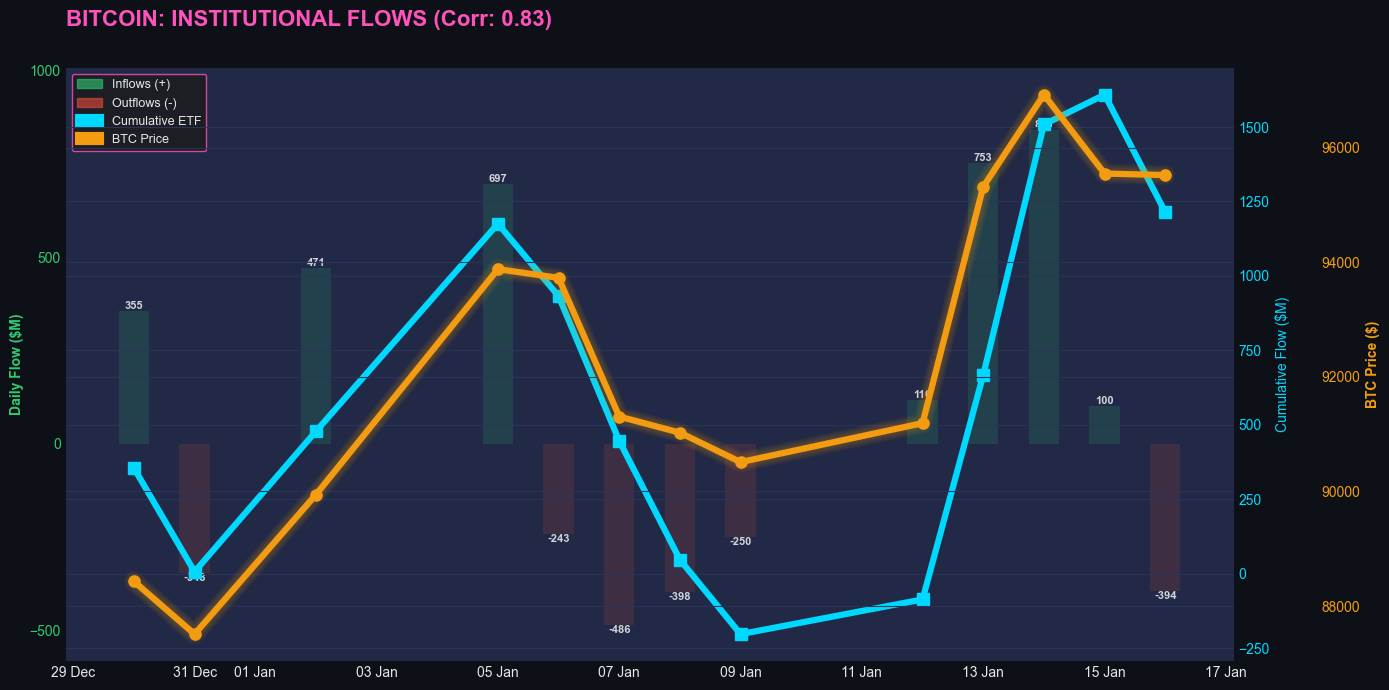

In [9]:
# Force fresh data fetch
data_df, corr_val = fetch_combined_analytics()

if data_df is not None:
    # Check if we really got 78 days
    if len(data_df) > 0:
        plot_correlation_dashboard(data_df, corr_val)
    else:
        print("[!] DataFrame is empty. Check the source table.")